# Unit07 非線性方程式之求解

## 學習目標

非線性方程式的求解是化學工程計算中不可或缺的技能。無論是狀態方程式的計算、化學平衡系統的分析、反應器的穩態設計，還是分離程序的平衡級計算，都需要求解非線性方程式或非線性聯立方程組。

學習完本單元後，您將能夠：

- 理解非線性方程式系統的基本特性與多重解問題
- 掌握各種數值求解方法的原理與適用情境
- 熟練使用 SciPy 的 `scipy.optimize` 模組求解非線性方程式
- 運用適當的起始猜測值策略提高求解成功率
- 處理化工問題中的多重解並驗證解的物理意義
- 分析求解過程的穩定性與誤差
- 設計模組化、可靠的非線性方程式求解程式

## 內容大綱

本 Notebook 包含以下內容：

0. 環境設定與套件載入
1. 非線性方程式系統基礎
2. 數值方法理論基礎
3. SciPy 進階求解方法
4. 起始猜測值策略
5. 多重解問題處理
6. 化工問題中的應用
7. 數值穩定性與誤差分析
8. 程式設計最佳實踐
9. 總結

---
### 0. 環境設定

In [16]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit07_Nonlinear_Equations'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit07'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit07
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Nonlinear_Equations
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Nonlinear_Equations\figs


---
### 1. 載入套件

In [17]:
# 基礎套件
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# SciPy 優化模組
from scipy.optimize import root_scalar, fsolve, root, least_squares
from scipy.optimize import brentq, newton

# 設定 NumPy 顯示選項
np.set_printoptions(precision=6, suppress=True)

# 設定 Matplotlib 繪圖樣式
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy  版本: {np.__version__}")
import scipy
print(f"  scipy  版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy  版本: 1.23.5
  scipy  版本: 1.15.2
  matplotlib 版本: 3.10.8


---
## 1. 非線性方程式系統基礎

### 1.1 單變數非線性方程式

單變數非線性方程式可表示為 $f(x) = 0$ ，其中 $f(x)$ 為非線性函數。與線性方程式不同，非線性方程式可能具有：

- **無解**：方程式在實數範圍內無解
- **唯一解**：方程式僅有一個實數解
- **多重解**：方程式有多個實數解

**化工範例：Van der Waals 狀態方程式**

求解在特定溫度 $T$ 和壓力 $P$ 下，氣體的莫耳體積 $V$ ：

$$\left( P + \frac{a}{V^2} \right) (V - b) - RT = 0$$

根的數量取決於操作條件：
- 在**兩相區**（$T < T_c$ 且 $P < P_{sat}$）：三個根（液相根、無意義中間根、氣相根）
- 在**兩相區外**（高壓液態或高溫氣態）：只有一個根

以下以 CO₂（$T_c = 304.2$ K，$P_c = 73.8$ bar）在 300 K、50 bar 下為例，此條件接近但未進入典型兩相區，透過圖形法觀察根的分布：

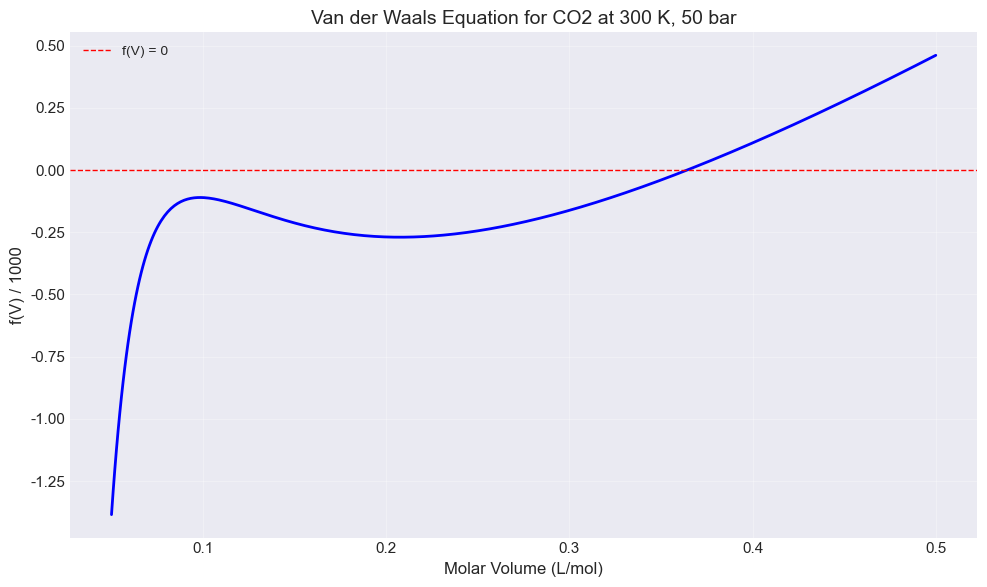

從圖形觀察到的根數量取決於操作條件（T, P 相對於臨界點的位置）
CO2 臨界點: Tc = 304.2 K, Pc = 73.8 bar
目前條件: T = 300 K, P = 50 bar


In [18]:
# Van der Waals 方程式參數（以 CO2 為例）
R = 8.314  # J/(mol·K)
T = 300    # K
P = 50e5   # Pa (50 bar)
a = 0.3658  # Pa·m^6/mol^2
b = 4.267e-5  # m^3/mol

# 定義 Van der Waals 方程式
def vdw_equation(V):
    """Van der Waals 方程式：(P + a/V^2)(V - b) - RT = 0"""
    return (P + a/V**2) * (V - b) - R * T

# 繪製函數圖形
V_range = np.linspace(5e-5, 5e-4, 500)
f_values = [vdw_equation(V) for V in V_range]

plt.figure(figsize=(10, 6))
plt.plot(V_range * 1e3, np.array(f_values) / 1e3, 'b-', linewidth=2)
plt.axhline(y=0, color='r', linestyle='--', linewidth=1, label='f(V) = 0')
plt.xlabel('Molar Volume (L/mol)', fontsize=12)
plt.ylabel('f(V) / 1000', fontsize=12)
plt.title('Van der Waals Equation for CO2 at 300 K, 50 bar', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'vdw_equation.png', dpi=150, bbox_inches='tight')
plt.show()

print("從圖形觀察到的根數量取決於操作條件（T, P 相對於臨界點的位置）")
print(f"CO2 臨界點: Tc = 304.2 K, Pc = 73.8 bar")
print(f"目前條件: T = {T} K, P = {P/1e5:.0f} bar")

### 1.2 多變數聯立非線性方程式

含 $n$ 個未知變數的聯立非線性方程組可表示為向量形式：

$$\mathbf{F}(\mathbf{x}) = \mathbf{0}$$

其中 $\mathbf{x} = [x_1, x_2, \ldots, x_n]^T$ 為未知變數向量。

**化工範例：CSTR 反應器穩態分析**

連續攪拌槽反應器（CSTR）的穩態物料與能量平衡可能有多個穩態解（多重穩態）。以下是簡化的 CSTR 系統範例：

In [19]:
# 定義簡化的 CSTR 系統
def cstr_equations(x):
    """
    CSTR 穩態方程組
    x[0]: 無因次轉化率
    x[1]: 無因次溫度
    """
    Da = 0.072     # Damköhler number
    B = 8.0        # 熱參數
    beta = 0.3     # 冷卻參數
    gamma = 20.0   # 活化能參數
    
    # 反應速率
    rate = (1 - x[0]) * np.exp(x[1] / (1 + x[1]/gamma))
    
    # 物料平衡
    f1 = -x[0] + Da * rate
    
    # 能量平衡
    f2 = -(1 + beta) * x[1] + B * Da * rate
    
    return np.array([f1, f2])

# 測試函數
x_test = np.array([0.1, 0.1])
print("測試點 x =", x_test)
print("F(x) =", cstr_equations(x_test))
print("\n此系統需要透過數值方法求解，且可能有多個穩態解")

測試點 x = [0.1 0.1]
F(x) = [-0.028421  0.442636]

此系統需要透過數值方法求解，且可能有多個穩態解


---
## 2. 數值方法理論基礎

### 2.1 Bisection 法（二分法）

**基本原理**

二分法是最簡單且最可靠的求根方法，基於中間值定理。若 $f(a) \cdot f(b) < 0$ ，則在區間 $[a, b]$ 內必存在至少一個根。

**演算步驟**
1. 確認初始區間 $[a, b]$ 滿足 $f(a) \cdot f(b) < 0$（符號相反）
2. 計算中點 $c = (a + b) / 2$
3. 評估 $f(c)$ 並更新區間
4. 重複直到收斂

**優點**：保證收斂、不需要導數  
**缺點**：收斂速度較慢（線性收斂）

以下先掃描 VdW 方程式的符號變化位置，再自動選取正確的 Bisection 區間：

In [20]:
def bisection(f, a, b, tol=1e-6, max_iter=100):
    """
    Bisection 法求解 f(x) = 0
    
    Parameters:
    -----------
    f : function
        目標函數
    a, b : float
        初始區間端點（必須滿足 f(a)*f(b) < 0）
    tol : float
        容許誤差
    max_iter : int
        最大迭代次數
    
    Returns:
    --------
    root : float
        方程式的根
    """
    # 檢查初始條件
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError(f"f(a)={fa:.3e} 與 f(b)={fb:.3e} 必須異號，請重新選擇區間")
    
    print(f"{'Iter':<6} {'a':<12} {'b':<12} {'c':<12} {'f(c)':<12}")
    print("-" * 60)
    
    c = a
    for i in range(max_iter):
        c = (a + b) / 2
        fc = f(c)
        
        print(f"{i:<6} {a:<12.6e} {b:<12.6e} {c:<12.6e} {fc:<12.6e}")
        
        if abs(fc) < tol or abs(b - a) < tol:
            print(f"\n✓ 收斂！找到根 x = {c:.8f}")
            return c
        
        if f(a) * fc < 0:
            b = c
        else:
            a = c
    
    print(f"\n✗ 達到最大迭代次數 {max_iter}")
    return c

# 先掃描 VdW 方程式的符號變化，確定正確區間
V_scan = np.linspace(6e-5, 5e-4, 1000)
f_scan = np.array([vdw_equation(V) for V in V_scan])

print("掃描 VdW 方程式的符號變化區間：")
sign_changes = []
for i in range(len(V_scan)-1):
    if f_scan[i] * f_scan[i+1] < 0:
        sign_changes.append((V_scan[i], V_scan[i+1]))
        print(f"  符號變化於 V ∈ [{V_scan[i]*1e3:.4f}, {V_scan[i+1]*1e3:.4f}] L/mol")

print()

# 使用 Bisection 法求解 VdW 方程式的氣相根
if sign_changes:
    a_bracket, b_bracket = sign_changes[-1]  # 取最後一個（氣相）
    print(f"使用 Bisection 法求解 Van der Waals 方程式的氣相根：")
    print(f"使用區間 [{a_bracket*1e3:.4f}, {b_bracket*1e3:.4f}] L/mol")
    print("=" * 60)
    gas_root = bisection(vdw_equation, a_bracket - 5e-5, b_bracket + 5e-5, tol=1e-12)
    print(f"\n氣相莫耳體積：{gas_root * 1000:.6f} L/mol")
else:
    print("在掃描範圍內未找到符號變化，請調整掃描範圍")

掃描 VdW 方程式的符號變化區間：
  符號變化於 V ∈ [0.3639, 0.3643] L/mol

使用 Bisection 法求解 Van der Waals 方程式的氣相根：
使用區間 [0.3639, 0.3643] L/mol
Iter   a            b            c            f(c)        
------------------------------------------------------------
0      3.139039e-04 4.143443e-04 3.641241e-04 -5.155239e-02
1      3.641241e-04 4.143443e-04 3.892342e-04 7.538978e+01
2      3.641241e-04 3.892342e-04 3.766792e-04 3.695637e+01
3      3.641241e-04 3.766792e-04 3.704017e-04 1.826675e+01
4      3.641241e-04 3.704017e-04 3.672629e-04 9.060202e+00
5      3.641241e-04 3.672629e-04 3.656935e-04 4.492351e+00
6      3.641241e-04 3.656935e-04 3.649088e-04 2.217390e+00
7      3.641241e-04 3.649088e-04 3.645165e-04 1.082164e+00
8      3.641241e-04 3.645165e-04 3.643203e-04 5.151172e-01
9      3.641241e-04 3.643203e-04 3.642222e-04 2.317352e-01
10     3.641241e-04 3.642222e-04 3.641732e-04 9.007957e-02
11     3.641241e-04 3.641732e-04 3.641486e-04 1.926064e-02
12     3.641241e-04 3.641486e-04 3.641364e-04 -1

### 2.2 Newton-Raphson 法

**基本原理**

Newton-Raphson 法透過函數的切線來逼近根：

$$x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}$$

**優點**：二次收斂（收斂速度非常快）  
**缺點**：需要計算導數，且對起始猜測值敏感

**多變數擴展**

對於多變數系統 $\mathbf{F}(\mathbf{x}) = \mathbf{0}$ ：

$$\mathbf{x}_{k+1} = \mathbf{x}_k - \mathbf{J}^{-1}(\mathbf{x}_k) \mathbf{F}(\mathbf{x}_k)$$

其中 $\mathbf{J}$ 為 Jacobian 矩陣。

In [21]:
def newton_raphson(f, df, x0, tol=1e-6, max_iter=50):
    """
    Newton-Raphson 法求解 f(x) = 0
    
    Parameters:
    -----------
    f : function
        目標函數
    df : function
        導數函數
    x0 : float
        起始猜測值
    tol : float
        容許誤差
    max_iter : int
        最大迭代次數
    
    Returns:
    --------
    root : float
        方程式的根
    """
    print(f"{'Iter':<6} {'x':<15} {'f(x)':<15} {'f prime(x)':<15}")
    print("-" * 60)
    
    x = x0
    for i in range(max_iter):
        fx = f(x)
        dfx = df(x)
        
        print(f"{i:<6} {x:<15.8e} {fx:<15.8e} {dfx:<15.8e}")
        
        if abs(fx) < tol:
            print(f"\n✓ 收斂！找到根 x = {x:.10f}")
            return x
        
        if abs(dfx) < 1e-12:
            print(f"\n✗ 導數接近零，無法繼續")
            return x
        
        x = x - fx / dfx
    
    print(f"\n✗ 達到最大迭代次數 {max_iter}")
    return x

# VdW 方程式的導數
def vdw_derivative(V):
    """Van der Waals 方程式對 V 的導數"""
    return (P + a/V**2) - 2*a*(V - b)/V**3

# 使用 Newton-Raphson 法求解氣相根（大體積）
print("使用 Newton-Raphson 法求解 Van der Waals 方程式的氣相根：")
print("=" * 60)
gas_root = newton_raphson(vdw_equation, vdw_derivative, x0=3e-4, tol=1e-10)
print(f"\n氣相莫耳體積：{gas_root * 1000:.6f} L/mol")

使用 Newton-Raphson 法求解 Van der Waals 方程式的氣相根：
Iter   x               f(x)            f prime(x)     
------------------------------------------------------------
0      3.00000000e-04  -1.61646511e+02 2.09175452e+06 
1      3.77277955e-04  3.87579017e+01  3.01138837e+06 
2      3.64407512e-04  7.67170404e-01  2.89044420e+06 
3      3.64142096e-04  3.45661582e-04  2.88783874e+06 
4      3.64141976e-04  7.04858394e-11  2.88783756e+06 

✓ 收斂！找到根 x = 0.0003641420

氣相莫耳體積：0.364142 L/mol


---
## 3. SciPy 進階求解方法

SciPy 的 `scipy.optimize` 模組提供了強大的非線性方程式求解器。主要函數包括：

| 函數 | 適用範圍 | 特點 |
|------|----------|------|
| `root_scalar()` | 單變數 | 現代化介面，支援多種方法 |
| `fsolve()` | 單/多變數 | 經典求解器，易於使用 |
| `root()` | 多變數 | 進階求解器，提供詳細資訊 |
| `least_squares()` | 過度定義系統 | 最小平方法求解 |

### 3.1 root_scalar() - 單變數求解

`root_scalar()` 是單變數求解的現代化介面，支援多種方法：

In [22]:

# 方法 1: Brent's method (需要區間)
# CO2 在 300K/50bar 只有一個氣相根（約 0.37 L/mol = 3.7e-4 m^3/mol）
# 使用跨越符號變化的區間
sol_brent = root_scalar(vdw_equation, bracket=[2e-4, 5e-4], method='brentq')

print("使用 root_scalar() 求解 Van der Waals 方程式")
print("=" * 60)
print("\n1. Brent's Method (需要區間)")
print(f"   氣相根: {sol_brent.root * 1000:.6f} L/mol")
print(f"   迭代次數: {sol_brent.iterations}")
print(f"   函數呼叫次數: {sol_brent.function_calls}")
print(f"   收斂: {sol_brent.converged}")

# 方法 2: Newton's method (需要導數和起始值)
sol_newton = root_scalar(vdw_equation, fprime=vdw_derivative, x0=3e-4, method='newton')

print("\n2. Newton's Method (需要導數)")
print(f"   氣相根: {sol_newton.root * 1000:.6f} L/mol")
print(f"   迭代次數: {sol_newton.iterations}")
print(f"   函數呼叫次數: {sol_newton.function_calls}")
print(f"   收斂: {sol_newton.converged}")

# 方法 3: Secant method (需要起始值，不需要導數)
sol_secant = root_scalar(vdw_equation, x0=3e-4, x1=2.5e-4, method='secant')

print("\n3. Secant Method (不需要導數)")
print(f"   氣相根: {sol_secant.root * 1000:.6f} L/mol")
print(f"   迭代次數: {sol_secant.iterations}")
print(f"   函數呼叫次數: {sol_secant.function_calls}")
print(f"   收斂: {sol_secant.converged}")


使用 root_scalar() 求解 Van der Waals 方程式

1. Brent's Method (需要區間)
   氣相根: 0.364142 L/mol
   迭代次數: 8
   函數呼叫次數: 9
   收斂: True

2. Newton's Method (需要導數)
   氣相根: 0.364142 L/mol
   迭代次數: 4
   函數呼叫次數: 8
   收斂: True

3. Secant Method (不需要導數)
   氣相根: 0.364142 L/mol
   迭代次數: 5
   函數呼叫次數: 6
   收斂: True


### 3.2 fsolve() - 經典求解器

`fsolve()` 是最常用的求解器，適用於單變數和多變數系統。使用簡單，但提供的資訊較少。

**單變數範例：**

In [23]:

# 使用 fsolve() 求解單變數問題
from scipy.optimize import fsolve
import warnings

# 求解氣相根
gas_root_fsolve = fsolve(vdw_equation, x0=3e-4)
print("fsolve() 求解 VdW 方程式（氣相）:")
print(f"氣相根: {gas_root_fsolve[0] * 1000:.6f} L/mol\n")

# 求解液相根（此條件 300K/50bar 接近臨界點，僅有一個氣相根）
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    liquid_root_fsolve, info_l, ier_l, _ = fsolve(vdw_equation, x0=8e-5, full_output=True)

if ier_l == 1 and abs(vdw_equation(liquid_root_fsolve[0])) < 1e-6:
    print(f"液相根: {liquid_root_fsolve[0] * 1000:.6f} L/mol")
else:
    print("液相根：此條件下（T=300K, P=50bar）不存在液相根")
    print("  （CO2 Tc=304.2K，操作條件接近臨界點，VdW 僅有一個氣相根）")

# 完整資訊版本
solution, info, ier, msg = fsolve(vdw_equation, x0=3e-4, full_output=True)
print(f"\n完整資訊:")
print(f"收斂旗標: {ier} (1 = 成功)")
print(f"函數呼叫次數: {info['nfev']}")
print(f"訊息: {msg}")


fsolve() 求解 VdW 方程式（氣相）:
氣相根: 0.364142 L/mol

液相根：此條件下（T=300K, P=50bar）不存在液相根
  （CO2 Tc=304.2K，操作條件接近臨界點，VdW 僅有一個氣相根）

完整資訊:
收斂旗標: 1 (1 = 成功)
函數呼叫次數: 10
訊息: The solution converged.


**多變數範例：CSTR 系統**

CSTR 系統多重穩態搜索

起始猜測值 1: [0.1 0.5]
穩態解: 轉化率 = 0.1440, 溫度 = 0.8860
殘差: 4.48e-16
✓ 找到新的穩態

起始猜測值 2: [0.45 2.5 ]
穩態解: 轉化率 = 0.4472, 溫度 = 2.7517
殘差: 4.48e-16
✓ 找到新的穩態

起始猜測值 3: [0.8 5. ]
穩態解: 轉化率 = 0.7646, 溫度 = 4.7050
殘差: 1.34e-14
✓ 找到新的穩態

總共找到 3 個穩態解


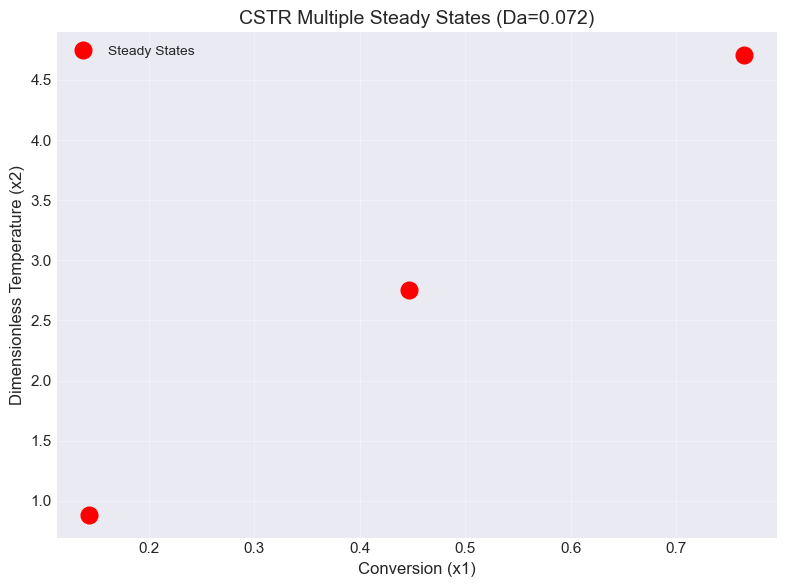

In [24]:

# 使用 fsolve() 求解 CSTR 系統（多重穩態）

# 嘗試三個不同的起始猜測值（根據物理分析選擇）
initial_guesses = [
    np.array([0.10, 0.50]),   # 低轉化率穩態（接近 x1≈0.14, x2≈0.89）
    np.array([0.45, 2.50]),   # 中間穩態（接近 x1≈0.45, x2≈2.75）
    np.array([0.80, 5.00])    # 高轉化率穩態（接近 x1≈0.77, x2≈4.70）
]

print("CSTR 系統多重穩態搜索")
print("=" * 60)

steady_states = []
for i, x0 in enumerate(initial_guesses, 1):
    sol = fsolve(cstr_equations, x0)
    residual = np.linalg.norm(cstr_equations(sol))
    
    print(f"\n起始猜測值 {i}: {x0}")
    print(f"穩態解: 轉化率 = {sol[0]:.4f}, 溫度 = {sol[1]:.4f}")
    print(f"殘差: {residual:.2e}")
    
    if residual < 1e-10:
        # 檢查是否為新解
        is_new = True
        for existing_sol in steady_states:
            if np.linalg.norm(sol - existing_sol) < 1e-4:
                is_new = False
                break
        
        if is_new:
            steady_states.append(sol)
            print("✓ 找到新的穩態")
        else:
            print("  (與已找到的穩態重複)")

print(f"\n總共找到 {len(steady_states)} 個穩態解")

# 視覺化穩態解
if len(steady_states) > 0:
    steady_states_array = np.array(steady_states)
    plt.figure(figsize=(8, 6))
    plt.plot(steady_states_array[:, 0], steady_states_array[:, 1], 'ro', markersize=12, label='Steady States')
    plt.xlabel('Conversion (x1)', fontsize=12)
    plt.ylabel('Dimensionless Temperature (x2)', fontsize=12)
    plt.title('CSTR Multiple Steady States (Da=0.072)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'cstr_steady_states.png', dpi=150, bbox_inches='tight')
    plt.show()


### 3.3 root() - 進階多變數求解器

`root()` 提供了更多的控制選項和詳細的求解資訊，特別適合複雜的多變數系統。支援多種方法：

- `hybr`：混合型 Powell 方法（預設）
- `lm`：Levenberg-Marquardt 方法
- `broyden1`、`broyden2`：擬牛頓法
- `krylov`、`df-sane`：大型系統專用方法

In [25]:
# 使用 root() 求解 CSTR 系統
from scipy.optimize import root

# 比較不同方法
methods = ['hybr', 'lm', 'broyden1']
x0 = np.array([0.5, 0.5])

print("使用 root() 求解 CSTR 系統（比較不同方法）")
print("=" * 70)

for method in methods:
    sol = root(cstr_equations, x0, method=method)
    
    print(f"\n方法: {method}")
    print(f"解: x1 = {sol.x[0]:.6f}, x2 = {sol.x[1]:.6f}")
    print(f"成功: {sol.success}")
    print(f"函數呼叫次數: {sol.nfev}")
    print(f"Jacobian 呼叫次數: {sol.njev if hasattr(sol, 'njev') else 'N/A'}")
    print(f"訊息: {sol.message}")
    
    # 驗證解
    residual = np.linalg.norm(cstr_equations(sol.x))
    print(f"殘差範數: {residual:.2e}")

使用 root() 求解 CSTR 系統（比較不同方法）

方法: hybr
解: x1 = 0.143969, x2 = 0.885965
成功: True
函數呼叫次數: 12
Jacobian 呼叫次數: N/A
訊息: The solution converged.
殘差範數: 4.48e-16

方法: lm
解: x1 = 0.143969, x2 = 0.885965
成功: True
函數呼叫次數: 18
Jacobian 呼叫次數: N/A
訊息: The relative error between two consecutive iterates is at most 0.000000
殘差範數: 2.24e-16

方法: broyden1
解: x1 = 0.143968, x2 = 0.885958
成功: True
函數呼叫次數: 7
Jacobian 呼叫次數: N/A
訊息: A solution was found at the specified tolerance.
殘差範數: 3.40e-06


---
## 4. 起始猜測值策略

選擇適當的起始猜測值對求解成功至關重要。以下是常用策略：

### 4.1 物理分析法

基於物理或化學原理估計合理範圍：

- 狀態方程式：氣相體積 > 液相體積
- 轉化率：範圍在 [0, 1]
- 溫度：不可為負（絕對溫度）
- 濃度：非負值

### 4.2 圖形法

繪製函數圖形，觀察可能的根位置：

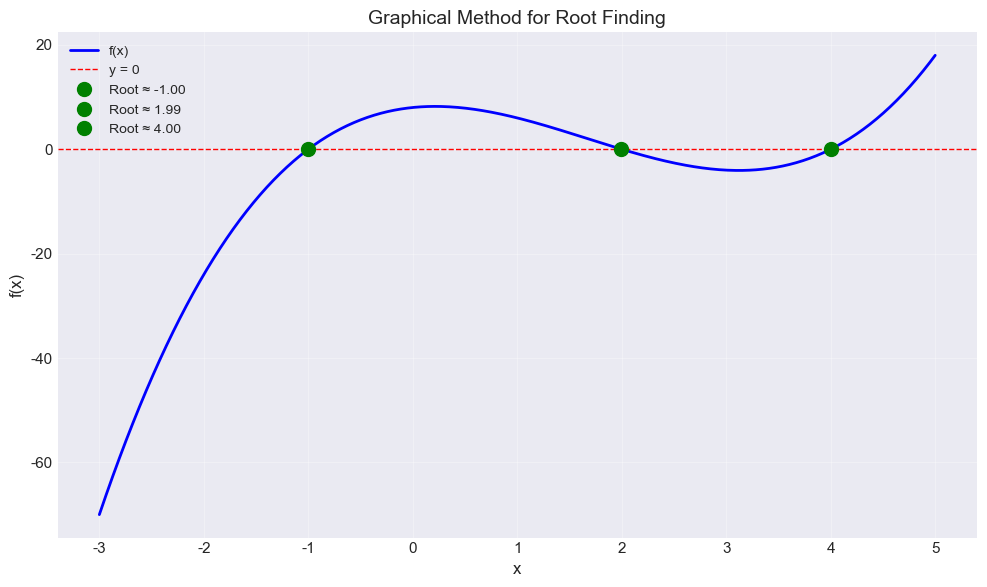

從圖形觀察到的根位置：
根 1: x ≈ -1.00
根 2: x ≈ 1.99
根 3: x ≈ 4.00

使用圖形法觀察到的位置作為起始猜測值：
根 1: x = -1.000000, f(x) = 8.88e-16
根 2: x = 2.000000, f(x) = 3.20e-14
根 3: x = 4.000000, f(x) = -8.70e-14


In [26]:

# 圖形法：繪製函數找出根的位置
def complex_equation(x):
    """複雜的非線性方程式"""
    return x**3 - 5*x**2 + 2*x + 8

x_plot = np.linspace(-3, 5, 500)
y_plot = complex_equation(x_plot)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
plt.axhline(y=0, color='r', linestyle='--', linewidth=1, label='y = 0')
plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Graphical Method for Root Finding', fontsize=14)
plt.legend(fontsize=11)

# 標記根的大致位置
approximate_roots = []
for i in range(len(x_plot)-1):
    if y_plot[i] * y_plot[i+1] < 0:
        approximate_roots.append((x_plot[i] + x_plot[i+1]) / 2)
        plt.plot((x_plot[i] + x_plot[i+1]) / 2, 0, 'go', markersize=10, label=f'Root ≈ {(x_plot[i] + x_plot[i+1]) / 2:.2f}')

plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'graphical_method.png', dpi=150, bbox_inches='tight')
plt.show()

print("從圖形觀察到的根位置：")
for i, root_approx in enumerate(approximate_roots, 1):
    print(f"根 {i}: x ≈ {root_approx:.2f}")

# 使用觀察到的位置作為起始猜測值
print("\n使用圖形法觀察到的位置作為起始猜測值：")
for i, x0 in enumerate(approximate_roots, 1):
    root_val = fsolve(complex_equation, x0)[0]
    print(f"根 {i}: x = {root_val:.6f}, f(x) = {complex_equation(root_val):.2e}")


### 4.3 多起始點搜索

對於可能有多個解的系統，使用網格搜索或隨機搜索：

In [27]:
# 多起始點搜索策略
def multi_start_search(func, bounds, n_starts=20, tol=1e-4):
    """
    多起始點搜索所有解
    
    Parameters:
    -----------
    func : function
        目標函數（可接受向量輸入）
    bounds : list of tuples
        每個變數的搜索範圍 [(x1_min, x1_max), (x2_min, x2_max), ...]
    n_starts : int
        起始點數量
    tol : float
        判斷解重複的容許誤差
    
    Returns:
    --------
    unique_solutions : list
        所有找到的唯一解
    """
    n_vars = len(bounds)
    unique_solutions = []
    
    # 生成隨機起始點
    np.random.seed(42)
    for i in range(n_starts):
        # 在指定範圍內隨機生成起始點
        x0 = np.array([np.random.uniform(low, high) for low, high in bounds])
        
        try:
            # 嘗試求解
            sol = fsolve(func, x0, full_output=True)
            x_sol = sol[0]
            info = sol[1]
            ier = sol[2]
            
            # 檢查是否成功收斂
            if ier == 1:
                residual = np.linalg.norm(func(x_sol))
                
                # 檢查殘差是否足夠小
                if residual < 1e-6:
                    # 檢查是否為新解
                    is_new = True
                    for existing_sol in unique_solutions:
                        if np.linalg.norm(x_sol - existing_sol) < tol:
                            is_new = False
                            break
                    
                    if is_new:
                        unique_solutions.append(x_sol)
        except:
            pass
    
    return unique_solutions

# 應用於 CSTR 系統
print("多起始點搜索 CSTR 系統的所有穩態：")
print("=" * 60)

bounds = [(0, 1), (0, 8)]  # 轉化率 [0,1], 溫度 [0,8]
all_solutions = multi_start_search(cstr_equations, bounds, n_starts=50)

print(f"找到 {len(all_solutions)} 個穩態解：\n")

for i, sol in enumerate(all_solutions, 1):
    print(f"穩態 {i}:")
    print(f"  轉化率 (x₁) = {sol[0]:.6f}")
    print(f"  溫度 (x₂) = {sol[1]:.6f}")
    residual = np.linalg.norm(cstr_equations(sol))
    print(f"  殘差 = {residual:.2e}\n")

多起始點搜索 CSTR 系統的所有穩態：
找到 3 個穩態解：

穩態 1:
  轉化率 (x₁) = 0.447159
  溫度 (x₂) = 2.751747
  殘差 = 1.16e-14

穩態 2:
  轉化率 (x₁) = 0.764561
  溫度 (x₂) = 4.704992
  殘差 = 4.49e-15

穩態 3:
  轉化率 (x₁) = 0.143969
  溫度 (x₂) = 0.885965
  殘差 = 4.48e-16



---
## 5. 多重解問題處理

### 5.1 多重解的偵測與驗證

非線性系統常有多個解，需要系統化的搜索與驗證：

1. **完整性**：是否找到所有解？
2. **物理意義**：解是否滿足物理限制？
3. **穩定性**：穩態解是否穩定？

**範例：Antoine 方程式求解泡點**

Antoine 方程式描述飽和蒸氣壓與溫度的關係：

$$P^{sat} = 10^{A - B/(C+T)}$$

求解泡點時需要滿足：

$$\sum_{i} x_i P_i^{sat}(T) = P_{total}$$

In [28]:
# 泡點計算範例：苯-甲苯混合物
def antoine_equation(T, A, B, C):
    """
    Antoine 方程式計算飽和蒸氣壓
    T: 溫度 (°C)
    P: 壓力 (mmHg)
    """
    return 10**(A - B/(C + T))

# Antoine 常數
# 苯 (Benzene)
A_benzene, B_benzene, C_benzene = 6.90565, 1211.033, 220.790
# 甲苯 (Toluene)
A_toluene, B_toluene, C_toluene = 6.95464, 1344.800, 219.482

def bubble_point_equation(T, x_benzene, P_total):
    """
    泡點方程式
    T: 溫度 (°C)
    x_benzene: 苯的液相莫耳分率
    P_total: 總壓 (mmHg)
    """
    P_sat_benzene = antoine_equation(T, A_benzene, B_benzene, C_benzene)
    P_sat_toluene = antoine_equation(T, A_toluene, B_toluene, C_toluene)
    
    x_toluene = 1 - x_benzene
    
    # 泡點條件：Σ x_i * P_i^sat = P_total
    return x_benzene * P_sat_benzene + x_toluene * P_sat_toluene - P_total

# 求解不同組成的泡點溫度
P_total = 760  # mmHg (1 atm)
x_benzene_values = [0.2, 0.5, 0.8]

print("苯-甲苯混合物泡點計算 (P = 760 mmHg)")
print("=" * 60)

for x_b in x_benzene_values:
    # 使用 root_scalar 求解
    sol = root_scalar(
        lambda T: bubble_point_equation(T, x_b, P_total),
        bracket=[80, 120],  # 預期溫度範圍
        method='brentq'
    )
    
    T_bubble = sol.root
    
    # 計算氣相組成
    P_sat_benzene = antoine_equation(T_bubble, A_benzene, B_benzene, C_benzene)
    P_sat_toluene = antoine_equation(T_bubble, A_toluene, B_toluene, C_toluene)
    y_benzene = x_b * P_sat_benzene / P_total
    
    print(f"\n液相組成 x_benzene = {x_b:.1f}")
    print(f"  泡點溫度: {T_bubble:.2f} °C")
    print(f"  氣相組成 y_benzene: {y_benzene:.4f}")
    print(f"  收斂: {sol.converged}, 迭代次數: {sol.iterations}")

苯-甲苯混合物泡點計算 (P = 760 mmHg)

液相組成 x_benzene = 0.2
  泡點溫度: 102.10 °C
  氣相組成 y_benzene: 0.3761
  收斂: True, 迭代次數: 8

液相組成 x_benzene = 0.5
  泡點溫度: 92.11 °C
  氣相組成 y_benzene: 0.7136
  收斂: True, 迭代次數: 8

液相組成 x_benzene = 0.8
  泡點溫度: 84.38 °C
  氣相組成 y_benzene: 0.9110
  收斂: True, 迭代次數: 7


---
## 6. 化工問題中的應用

### 6.1 狀態方程式

實際氣體的行為需要使用非線性狀態方程式描述，如：

- **Van der Waals (VdW)**：$(P + a/V^2)(V - b) = RT$
- **Soave-Redlich-Kwong (SRK)**
- **Peng-Robinson (PR)**

**範例：使用 SRK 方程式計算壓縮因子**

In [29]:

# SRK 方程式求解壓縮因子
import warnings

def srk_compressibility(Z, Tr, Pr, omega):
    """
    SRK 方程式（壓縮因子形式）
    Z: 壓縮因子
    Tr: 對比溫度 T/Tc
    Pr: 對比壓力 P/Pc
    omega: 偏心因子
    """
    # SRK 參數
    m = 0.480 + 1.574*omega - 0.176*omega**2
    alpha = (1 + m*(1 - np.sqrt(Tr)))**2
    
    a_srk = 0.42748 * alpha * Pr / Tr**2
    b_srk = 0.08664 * Pr / Tr
    
    # SRK 方程式（Z 的三次方程）
    return Z**3 - Z**2 + (a_srk - b_srk - b_srk**2)*Z - a_srk*b_srk

# CO2 的性質
Tc_co2 = 304.2  # K
Pc_co2 = 73.8   # bar
omega_co2 = 0.225

# 操作條件（使用獨立變數，避免覆蓋 VdW 的全域變數）
T_srk = 300  # K
P_srk = 50   # bar

Tr = T_srk / Tc_co2
Pr = P_srk / Pc_co2

print("使用 SRK 方程式計算 CO2 的壓縮因子")
print("=" * 60)
print(f"溫度: {T_srk} K (Tr = {Tr:.3f})")
print(f"壓力: {P_srk} bar (Pr = {Pr:.3f})")
print(f"偏心因子: {omega_co2}\n")

# 求解三個根（氣相、液相、中間根）
initial_guesses = [0.1, 0.5, 0.9]  # 液相、中間、氣相
roots_srk = []

for i, Z0 in enumerate(initial_guesses):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            Z_arr, info_z, ier_z, _ = fsolve(
                lambda Z: srk_compressibility(Z, Tr, Pr, omega_co2), Z0, full_output=True
            )
        Z_val = Z_arr[0]
        residual = abs(srk_compressibility(Z_val, Tr, Pr, omega_co2))
        
        if residual < 1e-8 and Z_val > 0 and ier_z == 1:
            # 檢查是否為新根
            is_new = all(abs(Z_val - r) > 1e-4 for r in roots_srk)
            if is_new:
                roots_srk.append(Z_val)
                print(f"根 {len(roots_srk)}: Z = {Z_val:.6f} (起始猜測值 Z0 = {Z0})")
    except:
        pass

print(f"\n找到 {len(roots_srk)} 個物理意義的根")
if len(roots_srk) == 1:
    print("（此條件接近臨界點，SRK 僅有一個實數根）")

if len(roots_srk) >= 1:
    R_bar = 83.14  # cm3·bar/(mol·K)
    Z_gas = max(roots_srk)
    V_gas = Z_gas * R_bar * T_srk / P_srk
    print(f"\n氣相壓縮因子: Z_G = {Z_gas:.6f}")
    print(f"氣相莫耳體積: {V_gas:.2f} cm3/mol")

if len(roots_srk) >= 3:
    Z_liquid = min(roots_srk)
    V_liquid = Z_liquid * R_bar * T_srk / P_srk
    print(f"液相壓縮因子: Z_L = {Z_liquid:.6f}")
    print(f"液相莫耳體積: {V_liquid:.2f} cm3/mol")


使用 SRK 方程式計算 CO2 的壓縮因子
溫度: 300 K (Tr = 0.986)
壓力: 50 bar (Pr = 0.678)
偏心因子: 0.225

根 1: Z = 0.694139 (起始猜測值 Z0 = 0.9)

找到 1 個物理意義的根
（此條件接近臨界點，SRK 僅有一個實數根）

氣相壓縮因子: Z_G = 0.694139
氣相莫耳體積: 346.26 cm3/mol


---
## 7. 數值穩定性與誤差分析

### 7.1 收斂準則

判斷求解是否成功收斂的準則：

1. **絕對殘差**：$\|\mathbf{F}(\mathbf{x})\| < \epsilon_{abs}$
2. **相對殘差**：$\|\mathbf{F}(\mathbf{x})\| / \|\mathbf{F}(\mathbf{x}_0)\| < \epsilon_{rel}$
3. **解的變化**：$\|\mathbf{x}_{k+1} - \mathbf{x}_k\| < \delta$

**範例：完整的收斂檢查**

In [30]:
def check_convergence(func, x_sol, x0=None, atol=1e-6, rtol=1e-6):
    """
    完整的收斂檢查函數
    
    Parameters:
    -----------
    func : function
        目標函數
    x_sol : array
        求解得到的解
    x0 : array, optional
        起始猜測值（用於計算相對殘差）
    atol : float
        絕對容許誤差
    rtol : float
        相對容許誤差
    
    Returns:
    --------
    bool : 是否收斂
    dict : 詳細的診斷資訊
    """
    residual = func(x_sol)
    abs_residual = np.linalg.norm(residual)
    
    diagnostics = {
        'absolute_residual': abs_residual,
        'converged_absolute': abs_residual < atol,
    }
    
    if x0 is not None:
        initial_residual = np.linalg.norm(func(x0))
        rel_residual = abs_residual / max(initial_residual, 1e-12)
        diagnostics['relative_residual'] = rel_residual
        diagnostics['converged_relative'] = rel_residual < rtol
        converged = diagnostics['converged_absolute'] or diagnostics['converged_relative']
    else:
        converged = diagnostics['converged_absolute']
    
    return converged, diagnostics

# 測試收斂檢查
print("完整的收斂檢查範例")
print("=" * 60)

x0_test = np.array([0.5, 0.5])
x_sol = fsolve(cstr_equations, x0_test)

converged, diag = check_convergence(cstr_equations, x_sol, x0_test)

print(f"起始猜測值: {x0_test}")
print(f"求解結果: {x_sol}")
print(f"\n收斂診斷:")
print(f"  絕對殘差: {diag['absolute_residual']:.2e}")
print(f"  相對殘差: {diag['relative_residual']:.2e}")
print(f"  絕對準則收斂: {diag['converged_absolute']}")
print(f"  相對準則收斂: {diag['converged_relative']}")
print(f"  整體收斂: {converged}")

if converged:
    print("\n✓ 解已成功收斂！")
else:
    print("\n✗ 警告：解未達到收斂準則！")

完整的收斂檢查範例
起始猜測值: [0.5 0.5]
求解結果: [0.143969 0.885965]

收斂診斷:
  絕對殘差: 4.48e-16
  相對殘差: 9.38e-16
  絕對準則收斂: True
  相對準則收斂: True
  整體收斂: True

✓ 解已成功收斂！


---
## 8. 程式設計最佳實踐

### 8.1 求解器選擇決策樹

根據問題特性選擇適當的求解器：

| 問題類型 | 推薦求解器 | 原因 |
|---------|-----------|------|
| 單變數 + 已知區間 | `root_scalar(..., method='brentq')` | 保證收斂、快速 |
| 單變數 + 有導數 | `root_scalar(..., method='newton')` | 二次收斂、效率高 |
| 單變數 + 無導數 | `root_scalar(..., method='secant')` | 不需導數、超線性收斂 |
| 多變數 + 小系統 | `fsolve()` | 簡單易用 |
| 多變數 + 需詳細資訊 | `root(..., method='hybr')` | 提供完整診斷 |
| 過度定義系統 | `least_squares()` | 最小平方法 |

### 8.2 模組化設計範例

建立可重用的求解器類別：

In [32]:
class NonlinearSolver:
    """
    通用非線性方程式求解器
    提供完整的求解、驗證和診斷功能
    """
    
    def __init__(self, equations, x0, jacobian=None, bounds=None):
        """
        Parameters:
        -----------
        equations : callable
            目標函數 F(x) = 0
        x0 : array_like
            起始猜測值
        jacobian : callable, optional
            Jacobian 矩陣函數
        bounds : list of tuples, optional
            變數的物理限制範圍
        """
        self.equations = equations
        self.x0 = np.array(x0)
        self.jacobian = jacobian
        self.bounds = bounds
        self.solution = None
        self.diagnostics = {}
    
    def solve(self, method='hybr', tol=1e-6):
        """求解方程組"""
        if self.jacobian is not None:
            sol = root(self.equations, self.x0, jac=self.jacobian, method=method, tol=tol)
        else:
            sol = root(self.equations, self.x0, method=method, tol=tol)
        
        self.solution = sol.x
        self.diagnostics['success'] = sol.success
        self.diagnostics['message'] = sol.message
        self.diagnostics['nfev'] = sol.nfev
        self.diagnostics['njev'] = sol.njev if hasattr(sol, 'njev') else None
        
        return self.solution
    
    def verify(self):
        """驗證解的正確性"""
        if self.solution is None:
            raise ValueError("尚未求解，請先呼叫 solve()")
        
        # 計算殘差
        residual = self.equations(self.solution)
        self.diagnostics['residual_norm'] = np.linalg.norm(residual)
        self.diagnostics['residual_max'] = np.max(np.abs(residual))
        
        # 檢查物理限制
        if self.bounds is not None:
            within_bounds = all(
                low <= x <= high 
                for x, (low, high) in zip(self.solution, self.bounds)
            )
            self.diagnostics['within_bounds'] = within_bounds
        
        return self.diagnostics
    
    def report(self):
        """產生求解報告"""
        print("=" * 70)
        print("非線性方程式求解報告")
        print("=" * 70)
        print(f"\n起始猜測值: {self.x0}")
        print(f"求解結果: {self.solution}")
        print(f"\n收斂狀態: {'✓ 成功' if self.diagnostics['success'] else '✗ 失敗'}")
        print(f"訊息: {self.diagnostics['message']}")
        print(f"函數呼叫次數: {self.diagnostics['nfev']}")
        if self.diagnostics['njev'] is not None:
            print(f"Jacobian 呼叫次數: {self.diagnostics['njev']}")
        print(f"\n殘差範數: {self.diagnostics['residual_norm']:.2e}")
        print(f"最大殘差: {self.diagnostics['residual_max']:.2e}")
        
        if 'within_bounds' in self.diagnostics:
            bounds_status = "✓ 在範圍內" if self.diagnostics['within_bounds'] else "✗ 超出範圍"
            print(f"物理限制: {bounds_status}")
        
        print("=" * 70)

# 使用範例
print("使用 NonlinearSolver 類別求解 CSTR 系統\n")

solver = NonlinearSolver(
    equations=cstr_equations,
    x0=[0.5, 0.5],
    bounds=[(0, 1), (0, 8)]  # 轉化率 [0,1], 溫度 [0,8]
)

# 求解
solution = solver.solve(method='hybr', tol=1e-8)

# 驗證
solver.verify()

# 產生報告
solver.report()


使用 NonlinearSolver 類別求解 CSTR 系統

非線性方程式求解報告

起始猜測值: [0.5 0.5]
求解結果: [0.143969 0.885965]

收斂狀態: ✓ 成功
訊息: The solution converged.
函數呼叫次數: 12

殘差範數: 4.48e-16
最大殘差: 4.44e-16
物理限制: ✓ 在範圍內


---
## 9. 總結

### 核心知識回顧

在本單元中，我們學習了非線性方程式求解的完整知識體系：

#### 1. 理論基礎
- 非線性方程式的特性（多重解、收斂性）
- 數值方法的原理（Bisection、Newton-Raphson、Secant 等）
- 收斂速率與穩定性分析

#### 2. SciPy 工具
- `root_scalar()`：單變數求解的現代化介面
- `fsolve()`：簡單易用的經典求解器
- `root()`：進階多變數求解器
- `least_squares()`：過度定義系統求解

#### 3. 實用技巧
- **起始猜測值策略**：物理分析、圖形法、多起始點搜索
- **多重解處理**：系統化搜索、物理意義驗證、穩定性分析
- **收斂診斷**：殘差檢查、物理限制驗證、結果分析

#### 4. 化工應用
- 狀態方程式（VdW、SRK、PR）
- 汽液平衡（泡點、露點計算）
- 化學平衡系統
- 反應器設計（CSTR 多重穩態）
- 傳遞現象（熱傳與質傳耦合）

### 關鍵技能

✓ 根據問題特性選擇合適的求解器  
✓ 設計有效的起始猜測值策略  
✓ 處理多重解問題  
✓ 分析解的物理意義與穩定性  
✓ 撰寫模組化、可靠的求解程式  

### 進階學習方向

1. **常微分方程式求解**（Unit09）：處理動態系統
2. **最適化**（Unit11）：學習約束與無約束最適化
3. **參數估計**（Unit12）：從實驗數據估計模型參數

### 實例演練

建議繼續學習以下範例，深入了解各類化工問題的求解技巧：

- **Example 01**：Van der Waals 狀態方程式
- **Example 02**：理想溶液泡點計算
- **Example 03**：化學反應平衡系統
- **Example 04**：CSTR 多重穩態分析
- **Example 05**：熱傳導乾燥過程
- **Example 06**：二元蒸餾塔設計

### 參考資料

**書籍**
- Buchanan, J.L. and Turner, P.R. (1992). *Numerical Methods and Analysis*. McGraw-Hill.
- Cutlip, M.B. and Shacham, M. (1999). *Problem Solving in Chemical Engineering with Numerical Methods*. Prentice Hall.

**線上資源**
- [SciPy Optimize Documentation](https://docs.scipy.org/doc/scipy/reference/optimize.html)
- [Numerical Recipes](http://numerical.recipes/)

---

**恭喜完成 Unit07 非線性方程式之求解！**

請繼續透過範例演練鞏固所學，並將這些技術應用於您自己的化工問題。